In [1]:
# weekly

In [52]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 0. rfa vs cfa with smooth data

In [53]:
session_path = '../data/co6/co6_10122023'
opto_session = MPOptoClass(session_path)

love


In [54]:
num_PCs=20
(X, causal_smooth), all_PCObjs = opto_session.format_nlags_PCA_smooth(bounds=opto_session.climbing_bounds, sigma=30, binsize=10, num_PCs=num_PCs, nlags=10, smooth_type='causal')
(nada, Y), nada = opto_session.format_nlags_PCA_smooth(bounds=opto_session.climbing_bounds, sigma=30, binsize=10, nlags=10, num_PCs = num_PCs, smooth_type='future')

In [55]:
X_CFA = X[:, :num_PCs*10]
Y_CFA = Y[:, :num_PCs]

X_RFA = X[:, num_PCs*10:]
Y_RFA = Y[:, num_PCs:]

In [56]:
true_y, predic_y = wiener_kfolds(X,Y, c=(3,5))
true_y_, predic_y_CFA = wiener_kfolds(X_CFA, Y, c=(3,5), k=4)
true_y, predic_y_RFA = wiener_kfolds(X_RFA, Y, c=(3,5), k=4)

0it [00:00, ?it/s]

Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 1668.100537200059
Testing c= 2782.559402207126
Testing c= 4641.588833612777
Testing c= 7742.63682681127
Testing c= 12915.496650148827
Testing c= 21544.346900318822
Testing c= 35938.13663804626
Testing c= 59948.42503189409
Testing c= 100000.0
best_c: 1000.0


1it [00:08,  8.10s/it]

Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 1668.100537200059
Testing c= 2782.559402207126
Testing c= 4641.588833612777
Testing c= 7742.63682681127
Testing c= 12915.496650148827
Testing c= 21544.346900318822
Testing c= 35938.13663804626
Testing c= 59948.42503189409
Testing c= 100000.0
best_c: 1000.0


2it [00:16,  8.50s/it]

...

best_c: 1000.0
Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 1668.100537200059
Testing c= 2782.559402207126
Testing c= 4641.588833612777
Testing c= 7742.63682681127
Testing c= 12915.496650148827
Testing c= 21544.346900318822
Testing c= 35938.13663804626
Testing c= 59948.42503189409
Testing c= 100000.0


3it [00:07,  2.64s/it]

best_c: 1000.0
Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 1668.100537200059
Testing c= 2782.559402207126
Testing c= 4641.588833612777
Testing c= 7742.63682681127
Testing c= 12915.496650148827
Testing c= 21544.346900318822
Testing c= 35938.13663804626
Testing c= 59948.42503189409
Testing c= 100000.0


4it [00:10,  2.61s/it]

best_c: 1000.0


In [57]:
cfa_all = weighted_r2(true_y[:, :num_PCs], predic_y[:, :num_PCs])
cfa_cfa = weighted_r2(true_y[:, :num_PCs], predic_y_CFA[:, :num_PCs])
cfa_rfa = weighted_r2(true_y[:, :num_PCs], predic_y_RFA[:, :num_PCs])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'prediciting CFA, smoothed opto data')

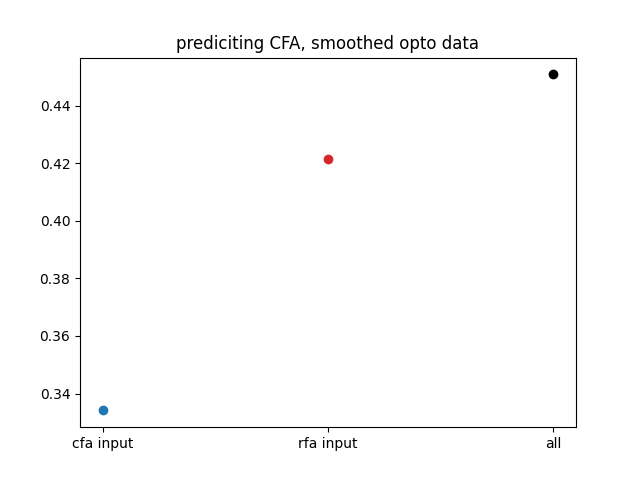

In [58]:
fig, ax = plt.subplots()
ax.scatter('cfa input', cfa_cfa, c='tab:blue')
ax.scatter('rfa input', cfa_rfa, c='tab:red')
ax.scatter('all', cfa_all, c='black')
ax.set_title('prediciting CFA, smoothed opto data')

In [59]:
rfa_all = weighted_r2(true_y[:, num_PCs:], predic_y[:, num_PCs:])
rfa_cfa = weighted_r2(true_y[:, num_PCs:], predic_y_CFA[:, num_PCs:])
rfa_rfa = weighted_r2(true_y[:, num_PCs:], predic_y_RFA[:, num_PCs:])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'prediciting RFA, smoothed opto data')

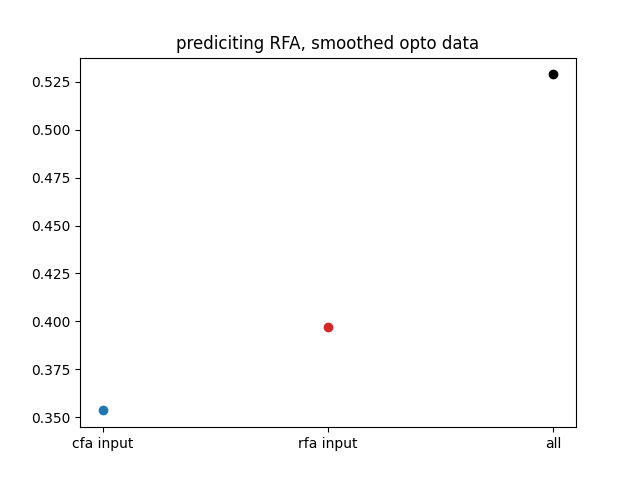

In [60]:
fig1, ax1 = plt.subplots()
ax1.scatter('cfa input', rfa_cfa, c='tab:blue')
ax1.scatter('rfa input', rfa_rfa, c='tab:red')
ax1.scatter('all', rfa_all, c='black')
ax1.set_title('prediciting RFA, smoothed opto data')

# mp experiments

In [78]:
session_path = '../data/mp_record/mp40/mp40_06152023'

session = MPRecordClass(session_path)


In [79]:
(X, Y), pca_objs  = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=20)


In [80]:
X_CFA = X[:, :num_PCs*10]
Y_CFA = Y[:, :num_PCs]

X_RFA = X[:, num_PCs*10:]
Y_RFA = Y[:, num_PCs:]

In [84]:
true_y, predic_y = wiener_kfolds(X,Y, c=5000, k=4)
true_y_, predic_y_CFA = wiener_kfolds(X_CFA, Y, c=(2,5), k=4)
true_y, predic_y_RFA = wiener_kfolds(X_RFA, Y, c=(2,5), k=4)

0it [00:00, ?it/s]

best_c: 5000


1it [00:00,  1.11it/s]

best_c: 5000


2it [00:01,  1.20it/s]

...

2it [00:16,  8.05s/it]

Sweeping ridge regularization using CV decoding on train data
Testing c= 100.0
Testing c= 215.44346900318845
Testing c= 464.15888336127773
Testing c= 1000.0
Testing c= 2154.4346900318824
Testing c= 4641.588833612777
Testing c= 10000.0
Testing c= 21544.346900318822
Testing c= 46415.888336127726
Testing c= 100000.0
best_c: 464.15888336127773


3it [00:24,  8.08s/it]

Sweeping ridge regularization using CV decoding on train data
Testing c= 100.0
Testing c= 215.44346900318845
Testing c= 464.15888336127773
Testing c= 1000.0
Testing c= 2154.4346900318824
Testing c= 4641.588833612777
Testing c= 10000.0
Testing c= 21544.346900318822
Testing c= 46415.888336127726
Testing c= 100000.0
best_c: 464.15888336127773


4it [00:32,  8.12s/it]


In [85]:
cfa_all = weighted_r2(true_y[:, :num_PCs], predic_y[:, :num_PCs])
cfa_cfa = weighted_r2(true_y[:, :num_PCs], predic_y_CFA[:, :num_PCs])
cfa_rfa = weighted_r2(true_y[:, :num_PCs], predic_y_RFA[:, :num_PCs])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'prediciting CFA, binned mp data')

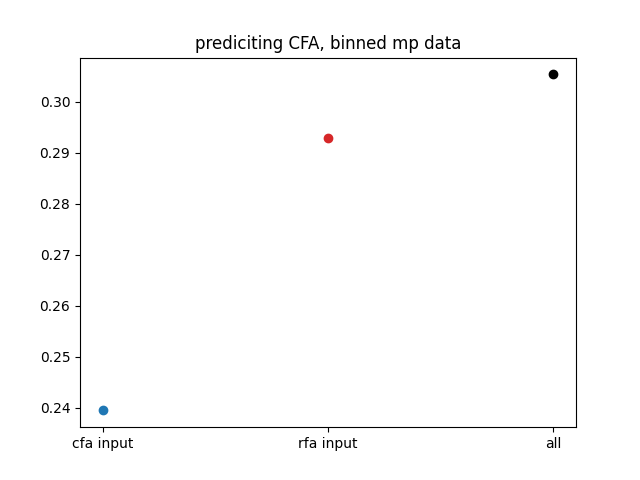

In [86]:
fig2, ax2 = plt.subplots()
ax2.scatter('cfa input', cfa_cfa, c='tab:blue')
ax2.scatter('rfa input', cfa_rfa, c='tab:red')
ax2.scatter('all', cfa_all, c='black')
ax2.set_title('prediciting CFA, binned mp data')

In [87]:
rfa_all = weighted_r2(true_y[:, num_PCs:], predic_y[:, num_PCs:])
rfa_cfa = weighted_r2(true_y[:, num_PCs:], predic_y_CFA[:, num_PCs:])
rfa_rfa = weighted_r2(true_y[:, num_PCs:], predic_y_RFA[:, num_PCs:])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'prediciting RFA, binned mp data')

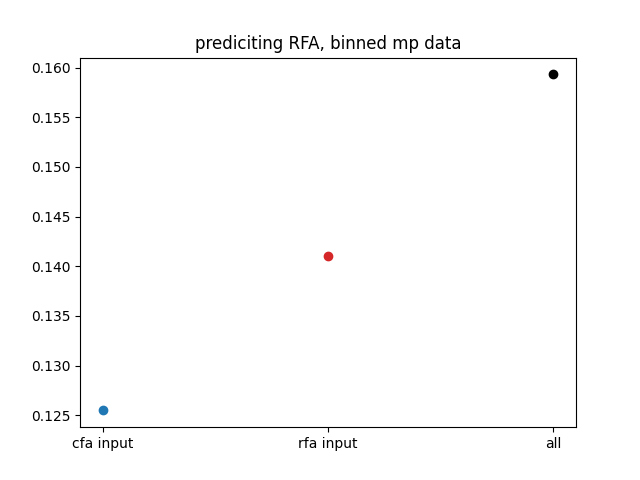

In [88]:
fig3, ax3 = plt.subplots()
ax3.scatter('cfa input', rfa_cfa, c='tab:blue')
ax3.scatter('rfa input', rfa_rfa, c='tab:red')
ax3.scatter('all', rfa_all, c='black')
ax3.set_title('prediciting RFA, binned mp data')

# reaching anecdote

In [89]:
session2 = ReachingClass('/home/diya/Documents/mp_opto/data/reaching/03272020')

this is for reaching


In [90]:
(X, Y), pca_objs  = session2.format_nlags_PCA(bounds=session2.reach_bounds, binsize=10, nlags=10, num_PCs=20)


In [91]:
X_CFA = X[:, :num_PCs*10]
Y_CFA = Y[:, :num_PCs]

X_RFA = X[:, num_PCs*10:]
Y_RFA = Y[:, num_PCs:]

In [92]:
true_y, predic_y = wiener_kfolds(X,Y, c=5000, k=4)
true_y_, predic_y_CFA = wiener_kfolds(X_CFA, Y, c=(2,5), k=4)
true_y, predic_y_RFA = wiener_kfolds(X_RFA, Y, c=(2,5), k=4)

2it [00:00, 13.26it/s]

best_c: 5000
best_c: 5000
best_c: 5000


4it [00:00, 13.11it/s]


best_c: 5000


0it [00:00, ?it/s]

...

Sweeping ridge regularization using CV decoding on train data
Testing c= 100.0
Testing c= 215.44346900318845
Testing c= 464.15888336127773
Testing c= 1000.0
Testing c= 2154.4346900318824
Testing c= 4641.588833612777
Testing c= 10000.0
Testing c= 21544.346900318822
Testing c= 46415.888336127726


3it [00:02,  1.40it/s]

Testing c= 100000.0
best_c: 464.15888336127773
Sweeping ridge regularization using CV decoding on train data
Testing c= 100.0
Testing c= 215.44346900318845
Testing c= 464.15888336127773
Testing c= 1000.0
Testing c= 2154.4346900318824
Testing c= 4641.588833612777
Testing c= 10000.0
Testing c= 21544.346900318822
Testing c= 46415.888336127726
Testing c= 100000.0


4it [00:02,  1.40it/s]

best_c: 464.15888336127773


In [93]:
cfa_all = weighted_r2(true_y[:, :num_PCs], predic_y[:, :num_PCs])
cfa_cfa = weighted_r2(true_y[:, :num_PCs], predic_y_CFA[:, :num_PCs])
cfa_rfa = weighted_r2(true_y[:, :num_PCs], predic_y_RFA[:, :num_PCs])

/tmp/ipykernel_39786/1906083310.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig4, ax4 = plt.subplots()
/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'prediciting CFA, binned mp data')

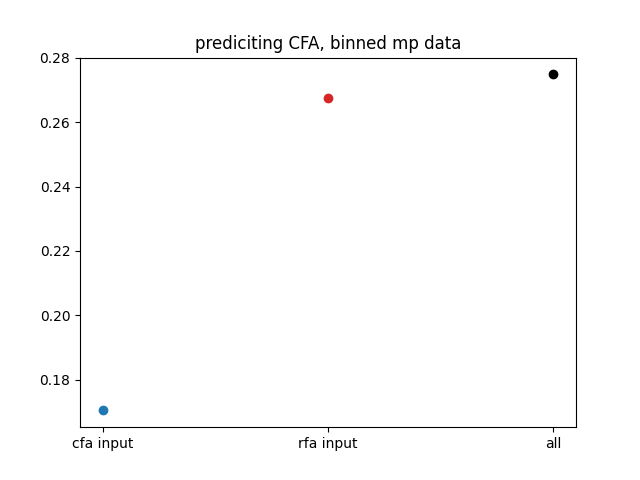

In [94]:
fig4, ax4 = plt.subplots()
ax4.scatter('cfa input', cfa_cfa, c='tab:blue')
ax4.scatter('rfa input', cfa_rfa, c='tab:red')
ax4.scatter('all', cfa_all, c='black')
ax4.set_title('prediciting CFA, binned mp data')

In [95]:
rfa_all = weighted_r2(true_y[:, num_PCs:], predic_y[:, num_PCs:])
rfa_cfa = weighted_r2(true_y[:, num_PCs:], predic_y_CFA[:, num_PCs:])
rfa_rfa = weighted_r2(true_y[:, num_PCs:], predic_y_RFA[:, num_PCs:])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'prediciting RFA, reaching')

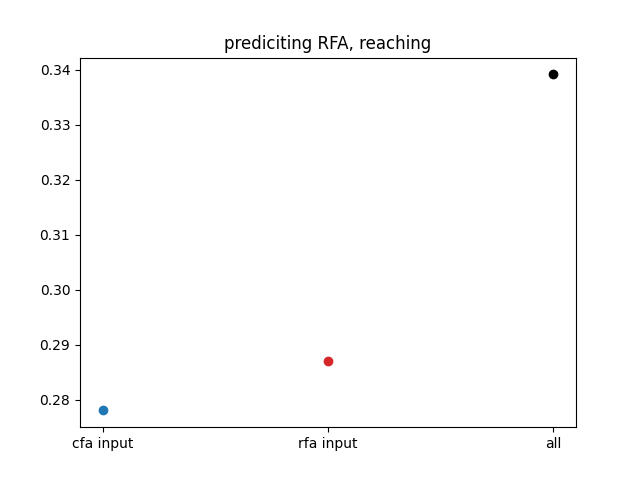

In [97]:
fig5, ax5 = plt.subplots()
ax5.scatter('cfa input', rfa_cfa, c='tab:blue')
ax5.scatter('rfa input', rfa_rfa, c='tab:red')
ax5.scatter('all', rfa_all, c='black')
ax5.set_title('prediciting RFA, reaching')

In [ ]:
# trash trash trash

In [75]:
X_CFA = X[:, :session2.num_CFA*10]
Y_CFA = Y[:, :session2.num_CFA]

X_RFA = X[:, session2.num_CFA*10:]
Y_RFA = Y[:, session2.num_CFA:]

In [79]:
#truue_y, predic_y = wiener_kfolds(X, Y, c=(3,6), k=4)
true_y_, predic_y_CFA = wiener_kfolds(X_CFA, Y, c=(3,6), k=4)
true_y, predic_y_RFA = wiener_kfolds(X_RFA, Y, c=(3,6), k=4)

0it [00:00, ?it/s]

Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 10000.0
Testing c= 100000.0
Testing c= 1000000.0


1it [00:01,  1.91s/it]

best_c: 10000.0
Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 10000.0
Testing c= 100000.0
Testing c= 1000000.0


2it [00:03,  1.81s/it]

...

2it [00:07,  3.61s/it]

Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 10000.0
Testing c= 100000.0
Testing c= 1000000.0
best_c: 10000.0


3it [00:10,  3.56s/it]

Sweeping ridge regularization using CV decoding on train data
Testing c= 1000.0
Testing c= 10000.0
Testing c= 100000.0
Testing c= 1000000.0
best_c: 10000.0


4it [00:14,  3.54s/it]


In [81]:
#print(weighted_r2(truue_y, predic_y))
print(weighted_r2(true_y[:, session2.num_CFA:], predic_y_CFA[:, session2.num_CFA:]))
print(weighted_r2(true_y[:, session2.num_CFA:], predic_y_RFA[:, session2.num_CFA:]))

0.27562844170831957
0.3362359131185402


In [71]:
session2.reach_bounds[:,1] - session2.reach_bounds[:,0]

array([558, 357, 419, 229, 354, 136, 308, 219, 285, 321, 278, 281, 368,
       503, 280, 286, 178, 325, 257, 354, 387, 173, 247, 280, 275, 174,
       267, 188, 251, 245, 272, 367, 243, 330, 227, 387, 306, 198, 135,
       273, 189, 300, 260, 215, 140, 180, 354, 137, 223, 192, 237, 175,
       179, 238, 215, 178, 171, 241, 198, 300, 151, 177, 156, 179, 162,
       180, 243, 242, 238, 209, 177, 236, 240, 180, 362, 245, 388, 244,
       331, 244, 253, 248, 200, 211, 207, 195, 171, 236, 233, 101, 203,
       229, 209,  47, 187, 196, 178, 180, 185, 201, 147, 170, 161, 151,
        79, 162, 258, 184, 182, 250, 140, 209, 150, 153, 260, 137, 186,
       181, 145, 156, 160, 179, 153, 208, 150, 193, 142, 196, 165, 187,
       166, 169, 202, 166, 169, 209, 205, 184, 215, 218, 200, 155, 193,
       230, 215, 223, 210, 218, 230], dtype=int32)

In [82]:
session.name

'mp40_06152023'

In [83]:
X.shape

(10280, 1890)

In [84]:
CFA, RFA = session.binner(bounds = session.climbing_bounds, fs=10, concat=True)

In [85]:
CFA.shape

(90542, 159)

In [88]:
np.average(CFA) / 0.01

4.029375018841806

In [89]:
np.average(RFA) / 0.01

2.614465463970698